# FIFA World Cup Winner Prediction: Elo-heuristic Baseline and XGBoost Models

This notebook starts from exactly two datasets:

1. `matches_preprocessed_readable.csv`: international matches with Elo ratings and an `is_world_cup` flag.
2. `matches.csv`: authoritative FIFA World Cup match data, including stage and knockout winners.

## Modeling tasks

- **All World Cup matches:** three outcomes — first-listed team wins, draw, or second-listed team wins.
- **Knockout matches:** binary winner — one of the two participating teams must advance.

The final output converts the internal relative class into the **actual team name**.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import ParameterSampler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 150)

In [2]:
#Read files
X_train_path = "../data/processed/X_train_processed.csv"
X_test_path = "../data/processed/X_test_processed.csv"
y_train_path = "../data/processed/y_train.csv"
y_test_path = "../data/processed/y_test.csv"

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)

# Verify shapes
print("X_train dataset shape:", X_train.shape)
print("X_test dataset shape:", X_test.shape)
print("y_train dataset shape:", y_train.shape)
print("y_test dataset shape:", y_test.shape)

display(X_train.head(3))

X_train dataset shape: (23192, 108)
X_test dataset shape: (4417, 108)
y_train dataset shape: (23192, 2)
y_test dataset shape: (4417, 2)


,num__home_elo,num__away_elo,num__elo_diff,num__home_elo_last_5,num__away_elo_last_5,num__elo_last_5_diff,num__home_goal_difference_last_5,num__away_goal_difference_last_5,num__goal_difference_last_5_diff,cat__tournament_ABCS Tournament,cat__tournament_AFC Asian Cup,cat__tournament_AFC Asian Cup qualification,cat__tournament_AFC Challenge Cup,cat__tournament_AFC Challenge Cup qualification,cat__tournament_AFC Solidarity Cup,cat__tournament_AFF Championship,cat__tournament_AFF Championship qualification,cat__tournament_African Cup of Nations,cat__tournament_African Cup of Nations qualification,cat__tournament_Afro-Asian Games,cat__tournament_Amílcar Cabral Cup,cat__tournament_Arab Cup,cat__tournament_Arab Cup qualification,cat__tournament_Asian Games,cat__tournament_Baltic Cup,cat__tournament_CECAFA Cup,cat__tournament_CFU Caribbean Cup,cat__tournament_CFU Caribbean Cup qualification,cat__tournament_CONCACAF Nations League,cat__tournament_CONCACAF Nations League qualification,cat__tournament_COSAFA Cup,cat__tournament_COSAFA Cup qualification,cat__tournament_Confederations Cup,cat__tournament_Copa América,cat__tournament_Copa América qualification,cat__tournament_Copa Confraternidad,cat__tournament_Copa Paz del Chaco,cat__tournament_Copa del Pacífico,cat__tournament_Corsica Cup,cat__tournament_Coupe de l'Outre-Mer,cat__tournament_Cup of Ancient Civilizations,cat__tournament_Cyprus International Tournament,cat__tournament_Dragon Cup,cat__tournament_Dunhill Cup,cat__tournament_Dynasty Cup,cat__tournament_EAFF Championship,cat__tournament_ELF Cup,cat__tournament_East Asian Games,cat__tournament_FIFA World Cup,cat__tournament_FIFA World Cup qualification,cat__tournament_Four Nations' Cup,cat__tournament_Friendly,cat__tournament_Gold Cup,cat__tournament_Gold Cup qualification,cat__tournament_Gulf Cup,cat__tournament_Indian Ocean Island Games,cat__tournament_Intercontinental Cup,cat__tournament_Joe Robbie Cup,cat__tournament_King Hassan II Tournament,cat__tournament_King's Cup,cat__tournament_Kirin Challenge Cup,cat__tournament_Kirin Cup,cat__tournament_Korea Cup,cat__tournament_Lunar New Year Cup,cat__tournament_Mahinda Rajapaksa Cup,cat__tournament_Malta International Tournament,cat__tournament_Melanesia Cup,cat__tournament_Merdeka Tournament,cat__tournament_Miami Cup,cat__tournament_Millennium Cup,cat__tournament_Nations Cup,cat__tournament_Nehru Cup,cat__tournament_Nile Basin Tournament,cat__tournament_Nordic Championship,cat__tournament_OSN Cup,cat__tournament_Oceania Nations Cup,cat__tournament_Oceania Nations Cup qualification,cat__tournament_Pacific Games,cat__tournament_Pacific Mini Games,cat__tournament_Palestine International Championship,cat__tournament_Philippine Peace Cup,cat__tournament_Prime Minister's Cup,cat__tournament_SAFF Cup,cat__tournament_SKN Football Festival,cat__tournament_Simba Tournament,cat__tournament_South Asian Games,cat__tournament_South Pacific Games,cat__tournament_Southeast Asian Games,cat__tournament_Superclásico de las Américas,cat__tournament_TIFOCO Tournament,cat__tournament_Three Nations Cup,cat__tournament_Tournoi de France,cat__tournament_Trans-Tasman Cup,cat__tournament_UEFA Euro,cat__tournament_UEFA Euro qualification,cat__tournament_UEFA Nations League,cat__tournament_UNCAF Cup,cat__tournament_UNIFFAC Cup,cat__tournament_USA Cup,cat__tournament_United Arab Emirates Friendship Tournament,cat__tournament_Unity Cup,cat__tournament_VFF Cup,cat__tournament_WAFF Championship,cat__tournament_Windward Islands Tournament,cat__neutral_False,cat__neutral_True,cat__is_world_cup_False,cat__is_world_cup_True
0,0.344179,0.552091,-0.219132,0.344937,0.552624,-0.218971,-0.217576,0.146451,-0.274160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

# Elo-based heuristic as baseline model
Build a simple model that predicts the result simply based on the rolling average elo ratings. 

Use the `num__elo_last_5_diff` column. Since all elo ratings have been scaled in **notbook 2**, if elo_diff > 0 = home wins, < 0 = away wins, draw otherwise

**From label dataset**
 * 0 = away win
 * 1 = draw
 * 2 = home win

**Note**: By looking at the data, the delta `num__elo_diff` and `num__elo_last_5_diff` is not big because the average is very close to the last elo rating before the match

In [14]:
def elo_heuristic_predict(X):
    elo_diff = X["num__elo_last_5_diff"]
    return np.where(
        elo_diff > 0, 2,  # home win
        np.where(elo_diff < 0, 0, 1)) # away wins else draw

In [4]:
# Generate predictions
y_bl_train_pred = elo_heuristic_predict(X_train)
y_bl_test_pred = elo_heuristic_predict(X_test)

# Evaluate
print("Training accuracy:", accuracy_score(y_train['match_result_encoded'], y_bl_train_pred))
print("Test accuracy:", accuracy_score(y_test['match_result_encoded'], y_bl_test_pred))

# Calculate logloss
elo_diff = X_test["num__elo_last_5_diff"].fillna(0)

# higher Elo difference -> higher home-win probability
home_prob = 1 / (1 + np.exp(-elo_diff))
draw_prob = np.full(len(X_test), 0.20)
away_prob = 1 - home_prob

# Reserve 20% probability for draws 
home_prob = home_prob * 0.80
away_prob = away_prob * 0.80
elo_prob = np.column_stack([
    away_prob,  # class 0
    draw_prob,  # class 1
    home_prob   # class 2
])

elo_logloss = log_loss(y_test["match_result_encoded"], elo_prob, labels=[0, 1, 2])

print("Elo heuristic log loss:", elo_logloss)

Training accuracy: 0.5532942393928941
Test accuracy: 0.5809372877518678
Elo heuristic log loss: 0.935342064233673


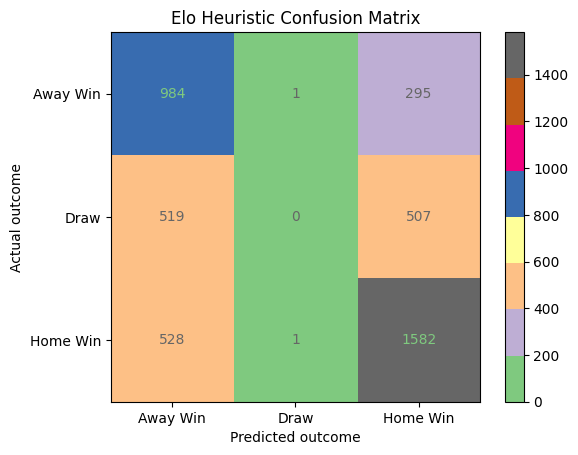

In [5]:
# Add confusion matrix
labels = [0, 1, 2]
class_names = ["Away Win", "Draw", "Home Win"]

cm = confusion_matrix(
    y_test['match_result_encoded'],
    y_bl_test_pred,
    labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format="d", cmap='Accent')
plt.title("Elo Heuristic Confusion Matrix")
plt.xlabel("Predicted outcome")
plt.ylabel("Actual outcome")
plt.show()

This model is extremely bad with predicting a draw since elo of two teams are rarely even

# XGBoost Model
Build XGBoost model to see whether we could improve the test accuracy and logloss compard to baseline model

In [6]:
# Hyperparameter tuning 
param_grid = {
    "n_estimators": [500, 800, 1200, 1500],
    "learning_rate": [0.01, 0.05, 0.08, 0.1, 0.2, 0.3],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0]
}

# keep random_state 1234 for replicability 
sampled_params = list(ParameterSampler(
        param_grid,
        n_iter=75,
        random_state=1234))

results = []

for i, params in enumerate(sampled_params):
    model = XGBClassifier(objective="multi:softmax", num_class=3, eval_metric="mlogloss",
        early_stopping_rounds=40, random_state=1234, n_jobs=-1, **params)
    model.fit(X_train, y_train['match_result_encoded'], eval_set=[(X_test, y_test['match_result_encoded'])], verbose=False)
    val_pred = model.predict(X_test)
    val_prob = model.predict_proba(X_test)
    val_accuracy = accuracy_score(y_test['match_result_encoded'], val_pred)
    val_logloss = log_loss(y_test['match_result_encoded'], val_prob, labels=[0,1,2])
    results.append({**params, "best_iteration": model.best_iteration, "validation_accuracy": val_accuracy, "val_logloss": val_logloss})

results_df = (pd.DataFrame(results).sort_values("validation_accuracy", ascending=False).reset_index(drop=True))
display(results_df.head(10))

,subsample,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,best_iteration,validation_accuracy,val_logloss
0,0.6,1500,3,6,0.30,0.9,12,0.604483,0.880066
1,0.9,500,8,4,0.05,0.8,159,0.601313,0.873131
2,0.6,1500,10,3,0.10,0.9,64,0.601087,0.872772
3,0.9,1500,10,3,0.01,1.0,900,0.601087,0.873621
4,0.6,800,8,3,0.20,0.8,33,0.601087,0.873148
5,1.0,500,8,3,0.05,0.6,193,0.601087,0.873404
6,0.9,1500,8,4,0.20,0.9,29,0.601087,0.874118
7,0.9,1200,8,4,0.20,1.0,30,0.600408,0.873895
8,0.9,1200,5,6,0.30,0.8,14,0.600408,0.876635
9,0.6,1200,3,2,0.10,0.6,110,0.600408,0.873032


In [7]:
# Build model with best parameters
best_param_config = results_df.iloc[0]

best_model = XGBClassifier(objective="multi:softmax", 
                           num_class=3, 
                           eval_metric=["merror", "mlogloss"],
                           early_stopping_rounds=40, 
                           random_state=1234, 
                           n_jobs=-1, 
                           n_estimators=int(best_param_config["n_estimators"]),
                           learning_rate=best_param_config["learning_rate"],
                           max_depth=int(best_param_config["max_depth"]),
                           min_child_weight=best_param_config["min_child_weight"],
                           subsample=best_param_config["subsample"],
                           colsample_bytree=best_param_config["colsample_bytree"])
best_model.fit(X_train, y_train['match_result_encoded'], 
               eval_set=[(X_train, y_train["match_result_encoded"]), (X_test, y_test['match_result_encoded'])], 
               verbose=False)
history = best_model.evals_result()


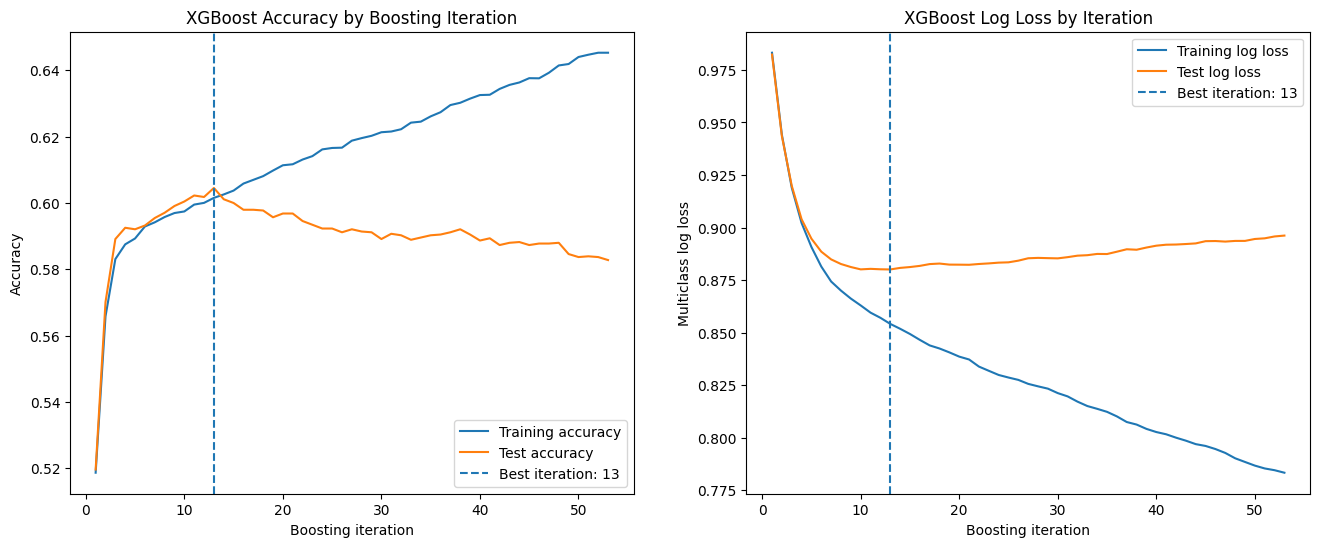


Training:
Accuracy: 0.6015005174197999
Log loss: 0.8541667070618865

Test:
Accuracy: 0.6044826805524111
Log loss: 0.8800663661552462


In [10]:
train_accuracy = [1 - error for error in history["validation_0"]["merror"]]
test_accuracy = [1 - error for error in history["validation_1"]["merror"]]

train_logloss = history["validation_0"]["mlogloss"]
test_logloss = history["validation_1"]["mlogloss"]

best_iteration = best_model.best_iteration 

# Plot accuracy and logloss for both training and test sets through iterations
iterations = range(1, len(train_accuracy) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(iterations, train_accuracy, label="Training accuracy")
axes[0].plot(iterations, test_accuracy,label="Test accuracy")
axes[0].axvline(best_iteration + 1, linestyle="--",
    label=f"Best iteration: {best_model.best_iteration + 1}")
axes[0].set_xlabel("Boosting iteration")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("XGBoost Accuracy by Boosting Iteration")
axes[0].legend()

# Logloss
axes[1].plot(iterations, train_logloss, label="Training log loss")
axes[1].plot(iterations, test_logloss,label="Test log loss")
axes[1].axvline(best_model.best_iteration + 1, linestyle="--",
    label=f"Best iteration: {best_iteration + 1}"
)
axes[1].set_title("XGBoost Log Loss by Iteration")
axes[1].set_xlabel("Boosting iteration")
axes[1].set_ylabel("Multiclass log loss")
axes[1].legend()

plt.show()

# Print out logloss and accuracy at best iteration
print("\nTraining:")
print("Accuracy:", train_accuracy[best_iteration])
print("Log loss:", train_logloss[best_iteration])

print("\nTest:")
print("Accuracy:", test_accuracy[best_iteration])
print("Log loss:", test_logloss[best_iteration])

# Subgroup evaluation
We're specifically interested in Fifa World Cup prediction but so far we have trained and evaluated all international matches.

This section is to breakdown performance by subgroups: Fifa World Cup matches vs Non-Fifa World Cup matches.

In [17]:
# Find the one-hot encoded FIFA World Cup column
# Note that because it's for evaluation we're only using the test datasets 
world_cup_columns = [col for col in X_test.columns if "FIFA World Cup" in col and "qualification" not in col.lower()]
print("World Cup columns found:", world_cup_columns)

world_cup_col = world_cup_columns[0]

# Create subgroup masks
world_cup_mask = X_test[world_cup_col] == 1
non_world_cup_mask = ~world_cup_mask

def evaluate_subgroup(subgroup_name, mask, y_test, pred, probs):
    mask = mask.to_numpy()
    y_group = y_test["match_result_encoded"].to_numpy()[mask]
    print("Number of matches in subgroup", subgroup_name, mask.sum())

    accuracy = accuracy_score(y_group, pred[mask])
    logloss = log_loss(y_group, probs[mask], labels=[0, 1, 2])

    return (accuracy, logloss)

World Cup columns found: ['cat__tournament_FIFA World Cup']


In [25]:
# Evaluate subgroups for Elo-based heuristic model
print("============================================================\nElo-based Heuristic Model Subgroup Eval\n============================================================")
eb_fifa_subgroup_acc, eb_fifa_subgroup_logloss = evaluate_subgroup("FIFA World Cup matches", 
                                                                   mask=world_cup_mask,
                                                                   y_test=y_test,
                                                                   pred=y_bl_test_pred,
                                                                   probs=elo_prob)
print("Accuracy:", eb_fifa_subgroup_acc)
print("Logloss:", eb_fifa_subgroup_logloss)
print()

eb_non_fifa_subgroup_acc, eb_non_fifa_subgroup_logloss = evaluate_subgroup("Non-FIFA World Cup matches", 
                                                                   mask=non_world_cup_mask,
                                                                   y_test=y_test,
                                                                   pred=y_bl_test_pred,
                                                                   probs=elo_prob)
print("Accuracy:", eb_non_fifa_subgroup_acc)
print("Logloss:", eb_non_fifa_subgroup_logloss)
print() 

# Evaluate subgroups for XGBoost Model
print("============================================================\nXGBoost Model Subgroup Eval\n============================================================")
xgb_predictions = best_model.predict(X_test)
xgb_probabilities = best_model.predict_proba(X_test)
xgb_fifa_subgroup_acc, xgb_fifa_subgroup_logloss = evaluate_subgroup("FIFA World Cup matches", 
                                                                   mask=world_cup_mask,
                                                                   y_test=y_test,
                                                                   pred=xgb_predictions,
                                                                   probs=xgb_probabilities)
print("Accuracy:", xgb_fifa_subgroup_acc)
print("Logloss:", xgb_fifa_subgroup_logloss)
print()

xgb_non_fifa_subgroup_acc, xgb_non_fifa_subgroup_logloss = evaluate_subgroup("Non-FIFA World Cup matches", 
                                                                   mask=non_world_cup_mask,
                                                                   y_test=y_test,
                                                                   pred=xgb_predictions,
                                                                   probs=xgb_probabilities)
print("Accuracy:", xgb_non_fifa_subgroup_acc)
print("Logloss:", xgb_non_fifa_subgroup_logloss)


Elo-based Heuristic Model Subgroup Eval
Number of matches in subgroup FIFA World Cup matches 66
Accuracy: 0.5757575757575758
Logloss: 1.0206908911433263

Number of matches in subgroup Non-FIFA World Cup matches 4351
Accuracy: 0.5810158584233509
Logloss: 0.934047414135756

XGBoost Model Subgroup Eval
Number of matches in subgroup FIFA World Cup matches 66
Accuracy: 0.5
Logloss: 1.0356538818071497

Number of matches in subgroup Non-FIFA World Cup matches 4351
Accuracy: 0.6060675706734084
Logloss: 0.8777062704568714
